# Round 002 — ตระกูล B: คะแนนรวม

**ทำอะไร:** รวมสัญญาณหลายตัวเป็นคะแนนเดียว (น้ำหนักเท่ากัน) แล้วเลือก top 20%

**อุปมา:** แทนที่จะเลือกนักกีฬาจากสถิติเดียว ใช้ค่าเฉลี่ยของหลายสถิติ เพื่อลดโอกาสเลือกผิดเพราะสถิติใดสถิติหนึ่งฟลุค

**อ่านผลอย่างไร:** เหมือน round 001 — สเปกใน rounds/round_002/HYPOTHESIS.md

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_002/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r002_B_QV_overall,0.509,0.64,0.681,0.112,0.125,-0.457,-0.376,False,False,0.405,0.033,63.417,51,1.017,1.137
1,r002_B_QV_sector,0.552,0.64,0.681,0.116,0.125,-0.436,-0.376,False,False,0.378,0.029,63.417,51,1.215,1.137
2,r002_B_QUAL_overall,0.755,0.64,0.681,0.151,0.125,-0.323,-0.376,False,False,0.838,0.240,63.417,51,0.890,1.137
3,r002_B_QUAL_sector,0.712,0.64,0.681,0.137,0.125,-0.351,-0.376,False,False,0.541,0.108,63.417,51,0.954,1.137
4,r002_B_FV_overall,0.489,0.64,0.681,0.104,0.125,-0.471,-0.376,False,False,0.216,0.011,58.583,50,1.160,1.137
5,r002_B_FV_sector,0.532,0.64,0.681,0.108,0.125,-0.413,-0.376,False,False,0.405,0.004,58.583,50,1.106,1.137
6,r002_B_SHYQ_overall,0.821,0.64,0.681,0.176,0.125,-0.384,-0.376,False,False,1.000,0.703,63.417,51,1.211,1.137
7,r002_B_SHYQ_sector,0.700,0.64,0.681,0.141,0.125,-0.401,-0.376,False,False,0.622,0.223,63.417,51,1.288,1.137
8,r002_B_QVI_overall,0.628,0.64,0.681,0.135,0.125,-0.406,-0.376,False,False,0.784,0.106,63.333,51,1.099,1.137
9,r002_B_QVI_sector,0.624,0.64,0.681,0.127,0.125,-0.402,-0.376,False,False,0.514,0.056,63.333,51,1.165,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


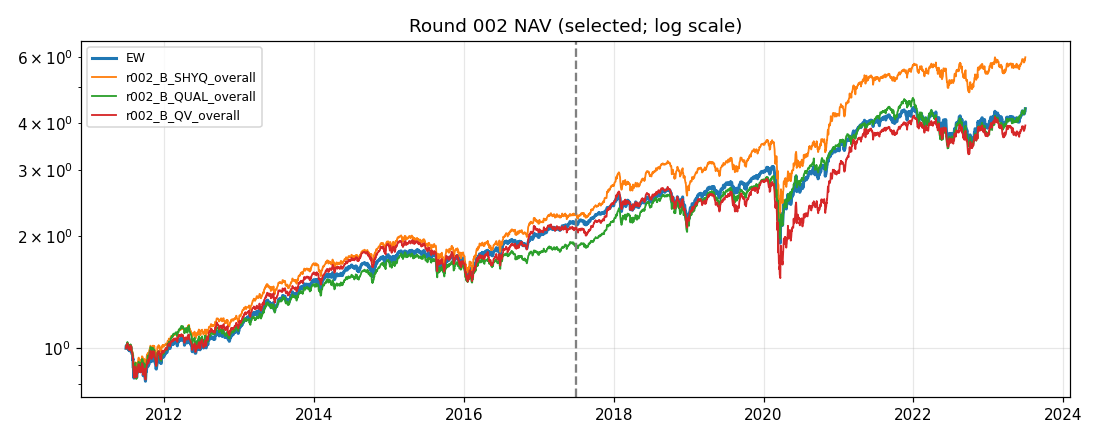

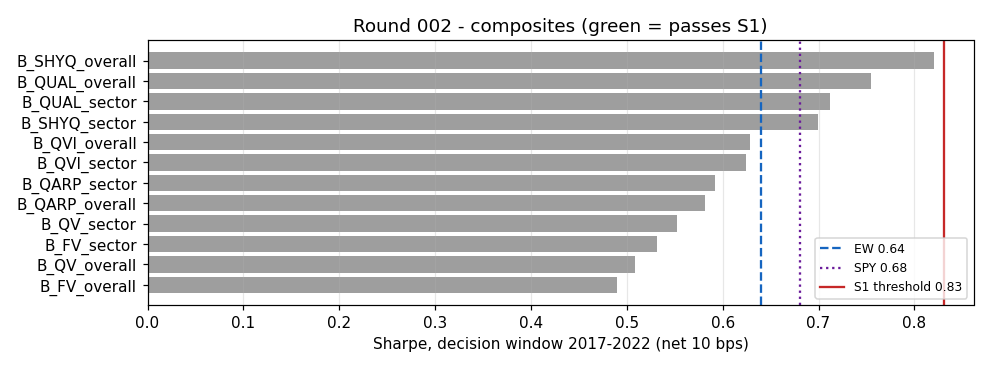

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_002_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_002/RESULTS.md").read_text()))

# Round 002 — ผล (ตระกูล B: คะแนนรวม) — **ไม่มีผู้เข้ารอบ**

- trial รอบนี้ 12 → สะสม **57**; ตารางเต็ม `results.csv`; กราฟ `figures/round_002_sharpe.png`, `figures/round_002_nav.png`
- benchmark ช่วงตัดสิน: EW(U) Sharpe 0.640 · SPY 0.681 → S1 ต้อง ≥ 0.831

| ผลสำคัญ | ตัวเลข |
|---|---|
| ผ่าน S1 | **ไม่มี** |
| ใกล้ที่สุด | `B_SHYQ_overall` (shareholder yield + quality): Sharpe 0.821, CAGR 17.6% vs EW 12.5%, S2 100%, DSR 0.703; ช่วงประกอบ 1.211 vs EW 1.137 |
| `B_QUAL_overall` (profitability + safety) | 0.755 — drawdown ต่ำกว่า EW (−32.3% vs −37.6%) แต่ไม่ถึง S1 |
| คะแนนรวมที่มี value (QV, FV, QARP, QVI) | 0.489–0.628 — **ไม่มีตัวไหนชนะ EW** |
| walk-forward | corr(Sharpe ส่วนเกินช่วงประกอบ, ช่วงตัดสิน) = −0.037; ตัวที่ดีที่สุดช่วงประกอบ `B_SHYQ_sector` (+0.150) ได้ +0.060 ในช่วงตัดสิน |

## การตีความ
- การใส่ value ลงไปดึงผลลงเสมอในช่วง 2017–2022 (value แพ้ growth หนักในหุ้นใหญ่ช่วงนี้) — ตรงกับ round 001
- shareholder yield + quality เป็นคู่ที่สม่ำเสมอที่สุดจนถึงตอนนี้ (ดีทั้งสองช่วง, S2 100%) แต่ยังไม่ถึงเกณฑ์ S1 และ DSR ต่ำ
- ไม่มีการลดเกณฑ์ — ไปต่อตระกูล C (สัญญาณราคา) ซึ่งงานวิจัย (Gu, Kelly & Xiu 2020) ชี้ว่าเป็นตัวเด่น
